# Recomputing Concordance Indices

This notebook sweeps every stored experiment under `Results/` and recomputes the concordance index (CI) using the saved model checkpoints. For each `(agent, dataset, seed)` combination we:
1. load the original configuration and instantiate the correct agent,
2. restore the trained parameters from `model.pt`,
3. rebuild the deterministic train/test split, and
4. evaluate the model again to obtain a fresh CI (and Brier score).

The table at the end compares the recomputed metrics with the values stored during the original runs.

In [10]:
import json
import pickle
from pathlib import Path

import pandas as pd
import yaml
from tqdm.auto import tqdm

import sys
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from baseline_cox import SA
from lambda_cox import LambdaSA
from deep_lambda_cox import DeepLambdaSA


In [26]:

RESULTS_ROOT = PROJECT_ROOT / "Results"
TEST_SIZE = 0.2  # Train/test split used during training

AGENT_MAP = {
    "SA": SA,
    "LambdaSA": LambdaSA,
    "DeepLambdaSA": DeepLambdaSA,
}

records = []
failures = []

datasets_of_interest = {"nasa", "churn_lastfm_months", "mimic", "big_rw"}
# datasets_of_interest = {"big_rw"}
seed_dirs = [
    p
    for p in RESULTS_ROOT.glob("*/**/seed_*")
    if len(p.relative_to(RESULTS_ROOT).parts) >= 7
    and p.relative_to(RESULTS_ROOT).parts[1] in datasets_of_interest
    and p.name.split('_')[-1].isdigit()
    and 0 <= int(p.name.split('_')[-1]) <= 10
]
seed_dirs.sort()
for seed_dir in tqdm(seed_dirs, desc="Seeds"):
    relative = seed_dir.relative_to(RESULTS_ROOT)
    parts = relative.parts
    if len(parts) < 7:
        failures.append({"path": str(seed_dir), "reason": "Unexpected directory depth"})
        continue

    agent_name, dataset_name, arch_name, lambda_dir, landmark_dir, exp_name, seed_name = parts[:7]
    config_path = seed_dir.parent / "config.yaml"
    model_path = seed_dir / "model.pt"
    prev_results_path = seed_dir / "results.json"

    if agent_name not in AGENT_MAP:
        failures.append({"path": str(seed_dir), "reason": f"Unknown agent {agent_name}"})
        continue
    if not config_path.exists():
        failures.append({"path": str(seed_dir), "reason": "Missing config.yaml"})
        continue
    if not model_path.exists():
        failures.append({"path": str(seed_dir), "reason": "Missing model.pt"})
        continue

    lambda_token = lambda_dir.split("_", 1)[1] if "_" in lambda_dir else None
    try:
        lambda_value = float(lambda_token) if lambda_token not in (None, "None") else None
    except ValueError:
        lambda_value = None

    landmark_token = landmark_dir.split("_", 1)[1] if "_" in landmark_dir else "False"
    landmark_value = True if landmark_token.lower() == "true" else False

    try:
        seed_value = int(seed_name.split("_")[-1])
    except ValueError:
        failures.append({"path": str(seed_dir), "reason": f"Could not parse seed from {seed_name}"})
        continue

    try:
        with open(config_path, "r") as fh:
            config_dict = yaml.safe_load(fh)
    except Exception as exc:
        failures.append({"path": str(seed_dir), "reason": f"Failed to load config: {exc}"})
        continue

    if lambda_value is not None:
        config_dict['lambda_'] = lambda_value
    config_dict['landmark'] = bool(landmark_value)

    AgentCls = AGENT_MAP[agent_name]
    try:
        agent = AgentCls(config_dict, seed_value)
    except Exception as exc:
        failures.append({"path": str(seed_dir), "reason": f"Failed to instantiate agent: {exc}"})
        continue

    try:
        with open(model_path, "rb") as fh:
            params = pickle.load(fh)
    except Exception as exc:
        failures.append({"path": str(seed_dir), "reason": f"Failed to load params: {exc}"})
        continue

    try:
        if agent_name == "DeepLambdaSA":
            agent.state = agent.state.replace(params=params, tgt_params=params)
        else:
            agent.state = agent.state.replace(params=params)
    except Exception as exc:
        failures.append({"path": str(seed_dir), "reason": f"Failed to restore parameters: {exc}"})
        continue

    try:
        _, test_gen = agent.get_train_test(test_size=TEST_SIZE)
        bs_new, ci_new = agent.eval(test_gen)
    except Exception as exc:
        failures.append({"path": str(seed_dir), "reason": f"Evaluation failed: {exc}"})
        continue

    prev_ci = prev_bs = None
    if prev_results_path.exists():
        try:
            with open(prev_results_path, "r") as fh:
                previous = json.load(fh)
            prev_ci = previous.get("ci")
            prev_bs = previous.get("bs")
        except Exception:
            prev_ci = prev_bs = None

    records.append({
        "agent": agent_name,
        "dataset": dataset_name,
        "architecture": arch_name,
        "lambda": lambda_value,
        "landmark": landmark_value,
        "experiment": exp_name,
        "seed": seed_value,
        "ci_new": float(ci_new),
        "ibs_new": float(bs_new),
        "ci_original": prev_ci,
        "ibs_original": prev_bs,
        "model_path": str(model_path),
    })

results_df = pd.DataFrame(records)
if not results_df.empty:
    results_df = results_df.sort_values(["agent", "dataset", "architecture", "lambda", "landmark", "experiment", "seed"]).reset_index(drop=True)





Seeds: 100%|██████████| 244/244 [03:02<00:00,  1.34it/s]


In [27]:
print(f"Recomputed entries: {len(results_df)}")
print(f"Failures: {len(failures)}")
if failures:
    display(pd.DataFrame(failures))

results_df.head()

if not results_df.empty:
    pivot_cols = ['agent', 'dataset', 'landmark', 'lambda']
    agg = (
        results_df
        .groupby(pivot_cols)[['ci_new', 'ibs_new']]
        .agg(['mean', 'std'])
        .sort_index()
    )
    display(agg)


Recomputed entries: 236
Failures: 8


,path,reason
0,/Users/mariana/Documents/col/lts4/survan/Resul...,Evaluation failed: No admissable pairs in the ...
1,/Users/mariana/Documents/col/lts4/survan/Resul...,Evaluation failed: No admissable pairs in the ...
2,/Users/mariana/Documents/col/lts4/survan/Resul...,Evaluation failed: No admissable pairs in the ...
3,/Users/mariana/Documents/col/lts4/survan/Resul...,Evaluation failed: No admissable pairs in the ...
4,/Users/mariana/Documents/col/lts4/survan/Resul...,Evaluation failed: No admissable pairs in the ...
5,/Users/mariana/Documents/col/lts4/survan/Resul...,Evaluation failed: No admissable pairs in the ...
6,/Users/mariana/Documents/col/lts4/survan/Resul...,Evaluation failed: No admissable pairs in the ...
7,/Users/mariana/Documents/col/lts4/survan/Resul...,Evaluation failed: No admissable pairs in the ...


ci_new            \
                                                      mean       std   
agent        dataset             landmark lambda                       
DeepLambdaSA big_rw              True     0.00    0.898283       NaN   
                                          0.10    0.925549  0.023561   
                                          0.90    0.962439  0.015516   
                                          0.95    0.956965  0.011818   
             churn_lastfm_months True     0.00    0.870227  0.020752   
                                          0.90    0.891154  0.024710   
                                          0.95    0.885654  0.028453   
             mimic               True     0.00    0.556608  0.272449   
                                          0.10    0.581316  0.327994   
                                          0.90    0.579187  0.314143   
                                          0.95    0.524004  0.224651   
             nasa                True     0.00    0.454871  0.091561   
                                          0.90    0.718357  0.107641   
                                          0.95    0.732542  0.116498   
SA           big_rw              False    0.90    0.871682  0.017021   
                                 True     0.90    0.941571  0.016317   
             churn_lastfm_months False    0.90    0.810838  0.033285   
                                 True     0.90    0.825541  0.041253   
             mimic               False    0.90    0.497826  0.006875   
                                 True     0.90    0.479589  0.091246   
             nasa                False    0.90    0.505095  0.015253   
                                 True     0.90    0.625054  0.041656   

                                                   ibs_new            
                                                      mean       std  
agent        dataset             landmark lambda                      
DeepLambdaSA big_rw              True     0.00    0.166716       NaN  
                                          0.10    0.125958  0.017165  
                                          0.90    0.029569  0.009686  
                                          0.95    0.032063  0.007353  
             churn_lastfm_months True     0.00    0.105752  0.006590  
                                          0.90    0.084673  0.016609  
                                          0.95    0.081551  0.017266  
             mimic               True     0.00    0.666815  0.035759  
                                          0.10    0.567663  0.036869  
                                          0.90    0.157831  0.076126  
                                          0.95    0.117067  0.036019  
             nasa                True     0.00    0.503319  0.049290  
                                          0.90    0.100669  0.024813  
                                          0.95    0.091938  0.033724  
SA           big_rw              False    0.90    0.072404  0.012681  
                                 True     0.90    0.047553  0.009364  
             churn_lastfm_months False    0.90    0.135575  0.051507  
                                 True     0.90    0.119712  0.035187  
             mimic               False    0.90    0.196080  0.051720  
                                 True     0.90    0.182524  0.043179  
             nasa                False    0.90    0.306044  0.068931  
                                 True     0.90    0.135221  0.021062

In [28]:
failures

[{'path': '/Users/mariana/Documents/col/lts4/survan/Results/DeepLambdaSA/mimic/transformer/lambda_0.0/landmark_True/exp_1/seed_0',
  'reason': 'Evaluation failed: No admissable pairs in the dataset.'},
 {'path': '/Users/mariana/Documents/col/lts4/survan/Results/DeepLambdaSA/mimic/transformer/lambda_0.1/landmark_True/exp_1/seed_0',
  'reason': 'Evaluation failed: No admissable pairs in the dataset.'},
 {'path': '/Users/mariana/Documents/col/lts4/survan/Results/DeepLambdaSA/mimic/transformer/lambda_0.9/landmark_True/exp_1/seed_0',
  'reason': 'Evaluation failed: No admissable pairs in the dataset.'},
 {'path': '/Users/mariana/Documents/col/lts4/survan/Results/DeepLambdaSA/mimic/transformer/lambda_0.95/landmark_True/exp_1/seed_0',
  'reason': 'Evaluation failed: No admissable pairs in the dataset.'},
 {'path': '/Users/mariana/Documents/col/lts4/survan/Results/DeepLambdaSA/mimic/transformer/lambda_0.95_previous/landmark_True/exp_1/seed_0',
  'reason': 'Evaluation failed: No admissable pair

In [29]:
results_df.head()

,agent,dataset,architecture,lambda,landmark,experiment,seed,ci_new,ibs_new,ci_original,ibs_original,model_path
0,DeepLambdaSA,big_rw,transformer,0.0,True,exp_1,0,0.898283,0.166716,0.898283,0.166716,/Users/mariana/Documents/col/lts4/survan/Resul...
1,DeepLambdaSA,big_rw,transformer,0.1,True,exp_1,0,0.928750,0.142142,0.928750,0.142142,/Users/mariana/Documents/col/lts4/survan/Resul...
2,DeepLambdaSA,big_rw,transformer,0.1,True,exp_1,1,0.940725,0.116983,0.940725,0.116983,/Users/mariana/Documents/col/lts4/survan/Resul...
3,DeepLambdaSA,big_rw,transformer,0.1,True,exp_1,2,0.936222,0.127998,0.936222,0.127998,/Users/mariana/Documents/col/lts4/survan/Resul...
4,DeepLambdaSA,big_rw,transformer,0.1,True,exp_1,3,0.950497,0.113566,0.950497,0.113566,/Users/mariana/Documents/col/lts4/survan/Resul...


In [30]:

output_csv = RESULTS_ROOT / "recomputed_ci.csv"
results_df.to_csv(output_csv, index=False)
print(f"Saved recomputed metrics to {output_csv}")


Saved recomputed metrics to /Users/mariana/Documents/col/lts4/survan/Results/recomputed_ci.csv


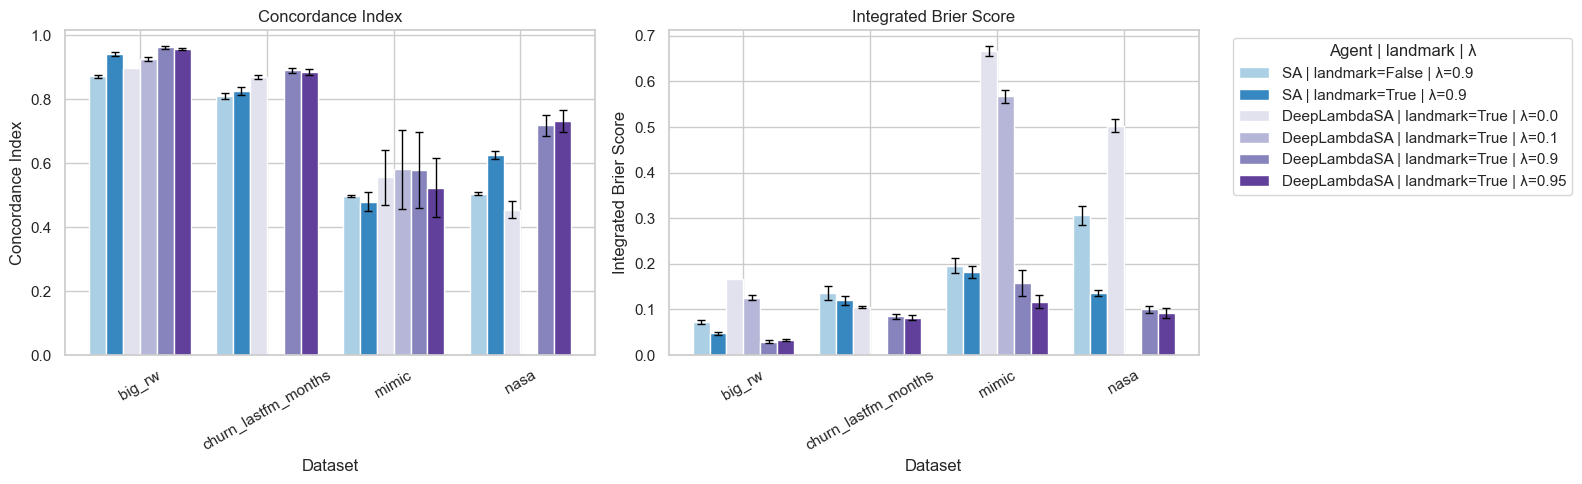

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

if not results_df.empty:
    group_cols = ['agent', 'dataset', 'landmark', 'lambda']
    agg_df = (
        results_df
        .groupby(group_cols)[['ci_new', 'ibs_new']]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    agg_df.columns = [
        'agent', 'dataset', 'landmark', 'lambda',
        'ci_mean', 'ci_std', 'ci_count',
        'ibs_mean', 'ibs_std', 'ibs_count'
    ]
    agg_df['ci_se'] = agg_df['ci_std'] / np.sqrt(agg_df['ci_count'].clip(lower=1))
    agg_df['ibs_se'] = agg_df['ibs_std'] / np.sqrt(agg_df['ibs_count'].clip(lower=1))

    agg_df = agg_df.sort_values(['agent', 'dataset', 'landmark', 'lambda']).reset_index(drop=True)
    agg_df['label'] = (
        agg_df['agent']
        + ' | landmark=' + agg_df['landmark'].astype(str)
        + ' | λ=' + agg_df['lambda'].astype(str)
    )

    datasets = sorted(agg_df['dataset'].unique())
    ordered_labels = []
    for agent in ['SA', 'LambdaSA', 'DeepLambdaSA']:
        agent_labels = agg_df.loc[agg_df['agent'] == agent, 'label'].unique().tolist()
        ordered_labels.extend(agent_labels)
    ordered_labels = [lbl for lbl in ordered_labels if lbl in agg_df['label'].unique()]

    label_colors = {}
    for agent, base_palette in {
        'SA': sns.color_palette('Blues', max(1, sum(lbl.startswith('SA') for lbl in ordered_labels))),
        'LambdaSA': sns.color_palette('Greens', max(1, sum(lbl.startswith('LambdaSA') for lbl in ordered_labels))),
        'DeepLambdaSA': sns.color_palette('Purples', max(1, sum(lbl.startswith('DeepLambdaSA') for lbl in ordered_labels))),
    }.items():
        agent_labels = [lbl for lbl in ordered_labels if lbl.startswith(agent)]
        for lbl, color in zip(agent_labels, base_palette):
            label_colors[lbl] = color

    x = np.arange(len(datasets))
    bar_groups = len(ordered_labels)
    total_width = 0.8
    bar_width = total_width / max(1, bar_groups)
    offsets = -total_width / 2 + bar_width / 2 + np.arange(bar_groups) * bar_width

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
    metrics = [
        ('ci_mean', 'ci_se', 'Concordance Index', axes[0]),
        ('ibs_mean', 'ibs_se', 'Integrated Brier Score', axes[1]),
    ]

    for mean_col, se_col, title, ax in metrics:
        for idx, label in enumerate(ordered_labels):
            label_rows = agg_df[agg_df['label'] == label]
            means = label_rows.set_index('dataset')[mean_col]
            ses = label_rows.set_index('dataset')[se_col]
            heights = []
            errors = []
            positions = []
            for di, dataset in enumerate(datasets):
                if dataset in means.index:
                    heights.append(means.loc[dataset])
                    errors.append(ses.loc[dataset])
                    positions.append(x[di] + offsets[idx])
            if not heights:
                continue
            color = label_colors.get(label, 'gray')
            bars = ax.bar(positions, heights, bar_width, color=color, label=label)
            for bar, err in zip(bars, errors):
                if np.isnan(err) or err == 0.0:
                    continue
                ax.errorbar(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                            yerr=err, fmt='none', ecolor='black', capsize=3, lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=30)
        ax.set_title(title)
        ax.set_xlabel('Dataset')
        ax.set_ylabel(title)

    handles, labels = axes[0].get_legend_handles_labels()
    labeled = dict(zip(labels, handles))
    if labeled:
        axes[1].legend(labeled.values(), labeled.keys(), title='Agent | landmark | λ',
                       bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('No results to plot.')
